# **Introduction to Support Vector Machines**

**Support Vector Machines (SVM)** are a set of supervised learning methods used for **classification, regression, and outliers detection**. Developed by Vladimir Vapnik and his colleagues, SVMs are powerful tools capable of performing **linear and non-linear classification**. They are known for their **robustness in high-dimensional spaces** and **effectiveness** in cases where the number of dimensions exceeds the number of samples.



**Key Concepts**:

* **Support Vectors**: The data points that are closest to the decision boundary. These points are critical in defining the position of the boundary.

* **Hyperplane**: A decision boundary that separates different classes. In two dimensions, it is a line; in three dimensions, a plane.

* **Margin**: The distance between the hyperplane and the nearest data point from either class.


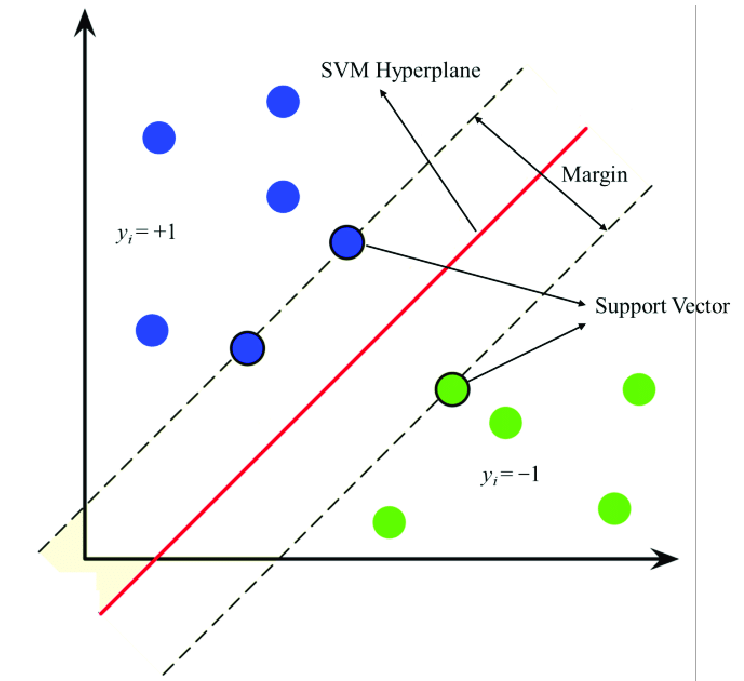

**Applications of SVM**:

* **Image Classification**: SVMs are used in image recognition and classification tasks.

* **Bioinformatics**: They are used for classifying genes, proteins, and other biological data.

* **Text Categorization**: SVMs classify documents into categories such as spam and non-spam emails.

* **Handwriting Recognition**: SVMs classify handwritten characters.


# **The Mathematics Behind SVM**

**Linear SVM**

In the simplest form, SVM is a linear classifier. Given a set of training data, the algorithm finds a hyperplane that best separates the data into classes.

**Objective**: Maximize the margin between the two classes.



Given training data
(
𝑥
1
,
𝑦
1
)
,
(
𝑥
2
,
𝑦
2
)
,
.
.
.
,
(
𝑥
𝑛
,
𝑦
𝑛
)
 ) where
𝑥
𝑖
∈
𝑅
𝑛
  and
𝑦
𝑖
∈
{
−
1
,
1
}, the goal is to find a hyperplane
𝑤
⋅
𝑥
+
𝑏
=
0 that separates the data.



The optimization problem can be formulated as:



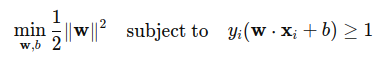

Where:

* 𝑤
is the normal vector to the hyperplane.
* 𝑏
is the offset from the origin.


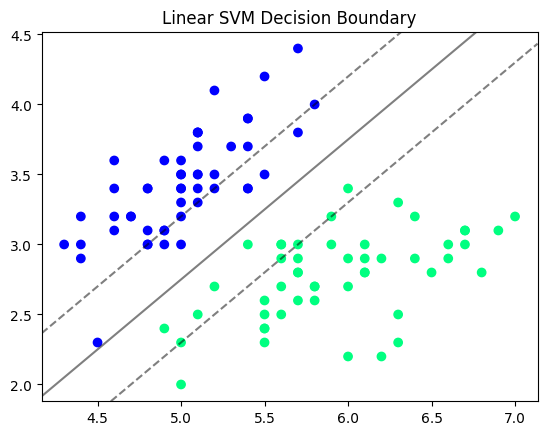

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

# Load dataset
iris = datasets.load_iris()
X = iris.data[:, :2]  # Only take the first two features.
y = iris.target

# Filter out two classes for binary classification
X = X[y != 2]
y = y[y != 2]

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Create SVM classifier
clf = SVC(kernel='linear', C=1)

# Train the classifier
clf.fit(X_train, y_train)

# Plot decision boundary
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='winter')
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

xx = np.linspace(xlim[0], xlim[1], 30)
yy = np.linspace(ylim[0], ylim[1], 30)
YY, XX = np.meshgrid(yy, xx)
xy = np.vstack([XX.ravel(), YY.ravel()]).T
Z = clf.decision_function(xy).reshape(XX.shape)

ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5,
           linestyles=['--', '-', '--'])
plt.title("Linear SVM Decision Boundary")
plt.show()


**Non-Linear SVM**

When data is not linearly separable, SVM can be extended using the kernel trick. The idea is to transform the input space into a higher-dimensional space where a linear separation is possible.

For instance, in a 2D space, points that form a circle can be linearly separable in a 3D space after a suitable transformation.



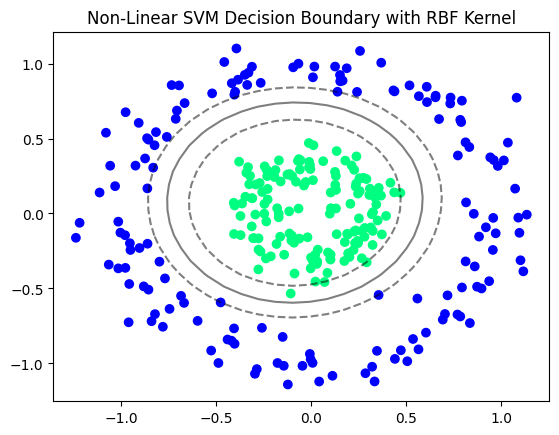

In [ ]:
from sklearn.datasets import make_circles
X, y = make_circles(n_samples=300, factor=.3, noise=.1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

clf = SVC(kernel='rbf', C=1000, gamma=0.1)
clf.fit(X_train, y_train)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap='winter')
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()
xx = np.linspace(xlim[0], xlim[1], 30)
yy = np.linspace(ylim[0], ylim[1], 30)
YY, XX = np.meshgrid(yy, xx)
xy = np.vstack([XX.ravel(), YY.ravel()]).T
Z = clf.decision_function(xy).reshape(XX.shape)

ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5,
           linestyles=['--', '-', '--'])
plt.title("Non-Linear SVM Decision Boundary with RBF Kernel")
plt.show()


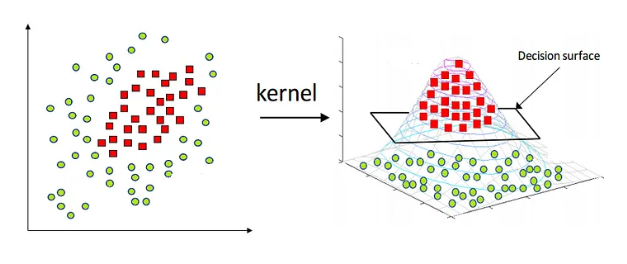

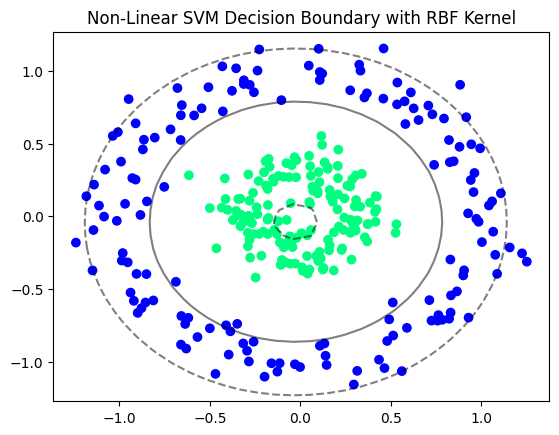

In [ ]:
from sklearn.datasets import make_circles
X, y = make_circles(n_samples=300, factor=.3, noise=.1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

clf = SVC(kernel='rbf', C=1, gamma=0.1)
clf.fit(X_train, y_train)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap='winter')
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()
xx = np.linspace(xlim[0], xlim[1], 30)
yy = np.linspace(ylim[0], ylim[1], 30)
YY, XX = np.meshgrid(yy, xx)
xy = np.vstack([XX.ravel(), YY.ravel()]).T
Z = clf.decision_function(xy).reshape(XX.shape)

ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5,
           linestyles=['--', '-', '--'])
plt.title("Non-Linear SVM Decision Boundary with RBF Kernel")
plt.show()

# **Kernel Trick**

Kernels are functions that take the input data and transform it into a higher-dimensional space. This allows SVM to create non-linear boundaries.


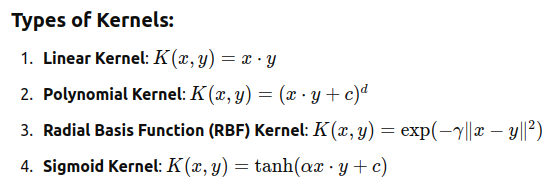

**Choosing the Right Kernel**:

* **Linear Kernel**: Best used when the data is linearly separable.

* **Polynomial Kernel**: Useful for image processing and other applications where interactions between features are important.

* **RBF Kernel**: Widely used in SVM classification because it can handle the case when the relation between class labels and attributes is non-linear.

* **Sigmoid Kernel**: Sometimes used as an alternative to neural networks.

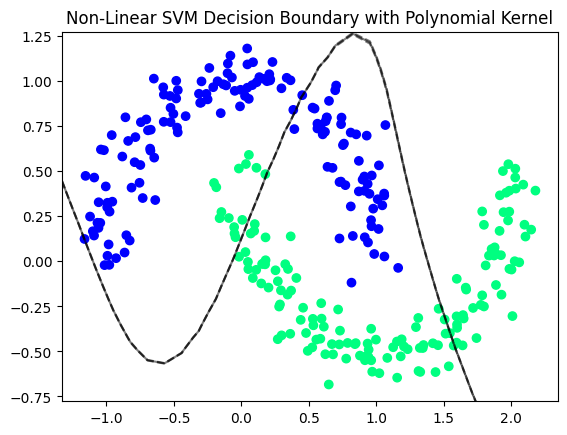

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

# Generate data
from sklearn.datasets import make_moons
X, y = make_moons(n_samples=300, noise=0.1)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Create SVM classifier with polynomial kernel
clf = SVC(kernel='poly', degree=3, C=100)

# Train the classifier
clf.fit(X_train, y_train)

# Plot decision boundary
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='winter')
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

xx = np.linspace(xlim[0], xlim[1], 30)
yy = np.linspace(ylim[0], ylim[1], 30)
YY, XX = np.meshgrid(yy, xx)
xy = np.vstack([XX.ravel(), YY.ravel()]).T
Z = clf.decision_function(xy).reshape(XX.shape)

ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5,
           linestyles=['--', '-', '--'])
plt.title("Non-Linear SVM Decision Boundary with Polynomial Kernel")
plt.show()


# **Soft Margin and Hard Margin**

**Hard Margin**

A hard margin SVM requires that all data points are classified correctly, which works well for linearly separable data but fails in the presence of noise or overlapping classes. This strict separation can lead to overfitting.



**Soft Margin** -
To address this, soft margin SVM introduces a slack variable
𝜉
𝑖
  that allows some misclassifications:



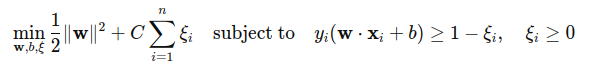

The parameter
𝐶
controls the trade-off between maximizing the margin and minimizing the classification error. A larger
𝐶
value puts more emphasis on classifying all training examples correctly, whereas a smaller
𝐶
value allows more slack (i.e., some misclassifications).

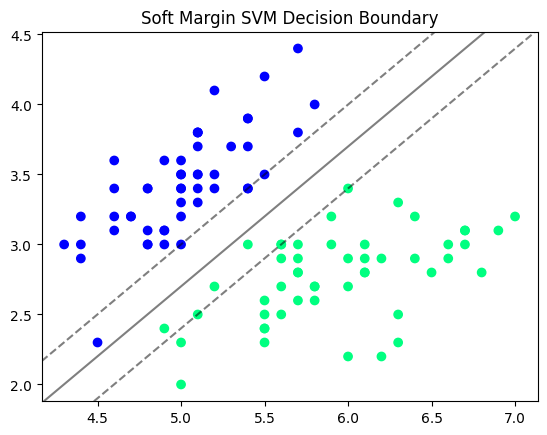

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

# Load dataset
iris = datasets.load_iris()
X = iris.data[:, :2]  # Only take the first two features.
y = iris.target

# Filter out two classes for binary classification
X = X[y != 2]
y = y[y != 2]

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Create SVM classifier with soft margin
clf = SVC(kernel='linear', C=5)  # Soft margin by setting a smaller C value

# Train the classifier
clf.fit(X_train, y_train)

# Plot decision boundary
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='winter')
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

xx = np.linspace(xlim[0], xlim[1], 30)
yy = np.linspace(ylim[0], ylim[1], 30)
YY, XX = np.meshgrid(yy, xx)
xy = np.vstack([XX.ravel(), YY.ravel()]).T
Z = clf.decision_function(xy).reshape(XX.shape)

ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5,
           linestyles=['--', '-', '--'])
plt.title("Soft Margin SVM Decision Boundary")
plt.show()


# **Hyperparameters in SVM**

Tuning hyperparameters is crucial for the performance of SVM.



**Key Hyperparameters**:

1) **C (Regularization parameter)**: Controls the trade-off between achieving a low error on the training data and minimizing the norm of the weights. It controls the cost of misclassification on the training data.
* **Large**
𝐶
: Fewer misclassifications but may lead to overfitting.
* **Small**
𝐶
: More misclassifications allowed, leading to a potentially more generalizable model.

2) **Kernel parameters:**

* **Gamma** (
𝛾
): Specific to the RBF kernel, it defines how far the influence of a single training example reaches. Low values mean ‘far’ and high values mean ‘close’.

* **Large**
𝛾
: The decision boundary is highly influenced by individual points, **leading to a more complex model**.
* **Small**
𝛾
: The decision boundary is **smoother and more generalized**.


3) **Degree** (
𝑑
): Specific to the polynomial kernel, it defines the degree of the polynomial used to find the optimal hyperplane.

3) **Coef0**: Used in polynomial and sigmoid kernels, it represents the independent term in the kernel function.



**Grid Search and Cross-Validation:**

To find the best hyperparameters, grid search combined with cross-validation is often used. This method exhaustively searches through a specified subset of hyperparameters and evaluates model performance using cross-validation.

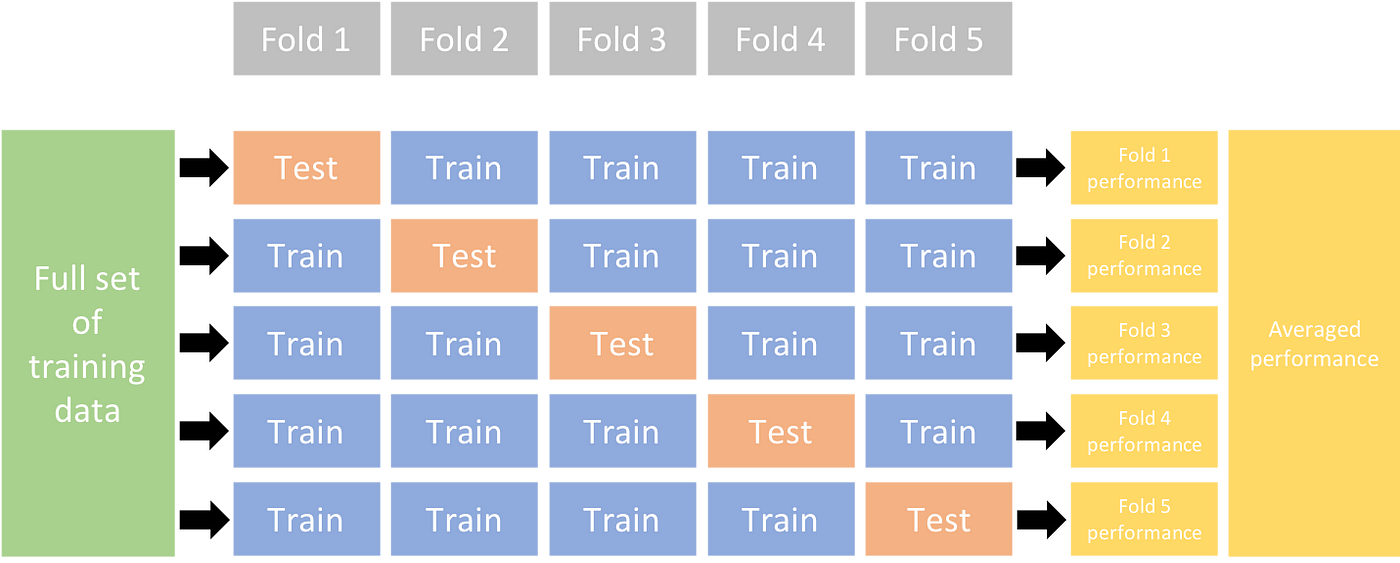

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split

# Load dataset
iris = datasets.load_iris()
X = iris.data[:, :2]  # Only take the first two features.
y = iris.target

# Filter out two classes for binary classification
X = X[y != 2]
y = y[y != 2]

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)

# Define the parameter grid
param_grid = {
    'C': [0.1, 1, 10, 1000],
    'gamma': [1, 0.1, 0.01, 0.001],
    'kernel': ['rbf', 'poly', 'sigmoid', 'linear']
}

# Create a base model
svc = SVC()

# Instantiate the grid search model
grid_search = GridSearchCV(estimator=svc, param_grid=param_grid, cv=5, scoring='accuracy', verbose=3, n_jobs=-1)

# Fit the grid search to the data
grid_search.fit(X_train, y_train)

# Print the best parameters and estimator
print(grid_search.best_params_)
print(grid_search.best_estimator_)

Fitting 5 folds for each of 64 candidates, totalling 320 fits
{'C': 0.1, 'gamma': 1, 'kernel': 'linear'}
SVC(C=0.1, gamma=1, kernel='linear')


In [ ]:
from sklearn import metrics

In [ ]:
# Create a base model
svc = SVC(kernel='linear')
svc.fit(X_train,y_train)
y_pred = svc.predict(X_test)
print(metrics.classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        30
           1       1.00      1.00      1.00        20

    accuracy                           1.00        50
   macro avg       1.00      1.00      1.00        50
weighted avg       1.00      1.00      1.00        50



# **Practical Examples**

**Example 1: Linear SVM with Linearly Separable Data**

In this example, we'll use a simple dataset where classes are linearly separable. We'll use the Iris dataset, focusing on two features to visualize the decision boundary.

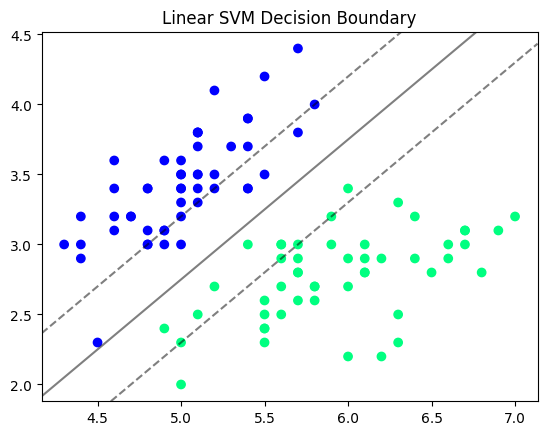

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

# Load dataset
iris = datasets.load_iris()
X = iris.data[:, :2]  # Only take the first two features.
y = iris.target

# Filter out two classes for binary classification
X = X[y != 2]
y = y[y != 2]

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Create SVM classifier
clf = SVC(kernel='linear', C=1.0)

# Train the classifier
clf.fit(X_train, y_train)

# Plot decision boundary
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='winter')
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

xx = np.linspace(xlim[0], xlim[1], 30)
yy = np.linspace(ylim[0], ylim[1], 30)
YY, XX = np.meshgrid(yy, xx)
xy = np.vstack([XX.ravel(), YY.ravel()]).T
Z = clf.decision_function(xy).reshape(XX.shape)

ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5,
           linestyles=['--', '-', '--'])
plt.title("Linear SVM Decision Boundary")
plt.show()


**Example 2: Non-Linear SVM with RBF Kernel**

In this example, we'll use a dataset where classes are not linearly separable and apply the RBF kernel to classify the data.

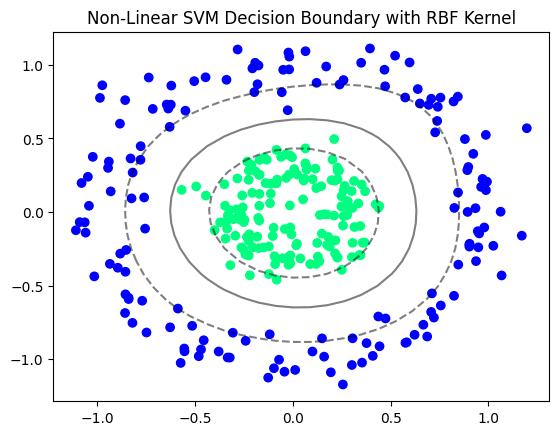

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

# Generate non-linearly separable data using make_circles
from sklearn.datasets import make_circles
X, y = make_circles(n_samples=300, factor=.3, noise=.1)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Create SVM classifier with RBF kernel
clf = SVC(kernel='rbf', C=1.0, gamma='scale')

# Train the classifier
clf.fit(X_train, y_train)

# Plot decision boundary
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='winter')
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

xx = np.linspace(xlim[0], xlim[1], 30)
yy = np.linspace(ylim[0], ylim[1], 30)
YY, XX = np.meshgrid(yy, xx)
xy = np.vstack([XX.ravel(), YY.ravel()]).T
Z = clf.decision_function(xy).reshape(XX.shape)

ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5,
           linestyles=['--', '-', '--'])
plt.title("Non-Linear SVM Decision Boundary with RBF Kernel")
plt.show()


**Example 3: Using Polynomial Kernel**

In this example, we will use a polynomial kernel to classify a dataset.

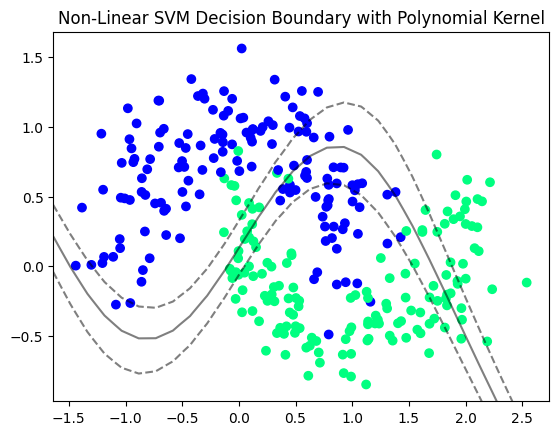

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

# Generate data
from sklearn.datasets import make_moons
X, y = make_moons(n_samples=300, noise=0.2)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Create SVM classifier with polynomial kernel
clf = SVC(kernel='sigmoid', gamma = 0.5, coef0= 0.01)

# Train the classifier
clf.fit(X_train, y_train)

# Plot decision boundary
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='winter')
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

xx = np.linspace(xlim[0], xlim[1], 30)
yy = np.linspace(ylim[0], ylim[1], 30)
YY, XX = np.meshgrid(yy, xx)
xy = np.vstack([XX.ravel(), YY.ravel()]).T
Z = clf.decision_function(xy).reshape(XX.shape)

ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5,
           linestyles=['--', '-', '--'])
plt.title("Non-Linear SVM Decision Boundary with Polynomial Kernel")
plt.show()


# **Conclusion**

**Support Vector Machines** are versatile and powerful tools in the machine learning toolbox. They can handle both linear and non-linear classification problems effectively. Understanding the theory behind SVM and practicing with various kernels and parameters is crucial for mastering this technique.

**Key Takeaways**:

* **Support Vectors**: Key data points that define the decision boundary.

* **Hyperplanes**: Decision boundaries separating different classes.

* **Kernels**: Functions transforming input data into higher-dimensional space to handle non-linear relationships.

* **Hyperparameters**:
𝐶 and
𝛾 are crucial for model performance and need careful tuning.


By leveraging the flexibility of the kernel trick and adjusting hyperparameters like
𝐶
and
𝛾
, SVM can be tailored to various datasets and problem types, making it a valuable asset for any machine learning practitioner.

